# Data Preparation and Modelling

### ML approach

* Observe the data and findout predictors and target variable. Based on the type of target variable check the suitability of algorithm
* Visualize the data for better appreciation of problem. Check where exactly your datapoint lies. (Distance based approach - kNN)
* Calculate conditional probabilities. (Probability based approach - Naive Bayes)
* Rule based approach - Decision tree
* Boundary based approach - Logistic Regression, SVM
* Ensemble based approach - Voting, Stacking, Bagging (RF), Boosting (Adaptive, Gradient and XG)
* All the above fails - Use Deeplearning based approach (ANN)

## Framework for Machine Learning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

from sklearn.multioutput import MultiOutputClassifier

### 1. Load the Given Data
* From .json, .csv, .sql and .pdf

In [ ]:
from sklearn.datasets import load_iris

iris = load_iris(as_frame = True)
features = iris.data
label = iris.target

In [ ]:
features.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
features.shape

(150, 4)

In [ ]:
label.head()

,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

### 2. Exploratory Data Analysis
* Clean the data
* Explore the Data Distribution of each variable and also identify outliers.
* Explore the Relationships between each pair of Inputs and Output.


**Exploratory Data Analysis - EDA (Data Understanding Phase)**  
This phase begins with collecting and reviewing the initial dataset to uncover patterns and assess overall structure. Through summary statistics and visual exploration, key insights are drawn about:

- **Data quality**: Detecting missing values, inconsistencies, or anomalies  
- **Data coverage**: Evaluating whether the current data sufficiently supports business goals or requires supplementation or feature engineering  
- **Variable relationships**: Identifying trends, correlations, and interactions among key attributes

In [ ]:
features.isna().sum()

,0
sepal length (cm),0
sepal width (cm),0
petal length (cm),0
petal width (cm),0


In [ ]:
features[features.duplicated(keep = False)]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
101,5.8,2.7,5.1,1.9
142,5.8,2.7,5.1,1.9


In [ ]:
data = features.drop_duplicates()
data.shape

(149, 4)

**Univariate Analysis**

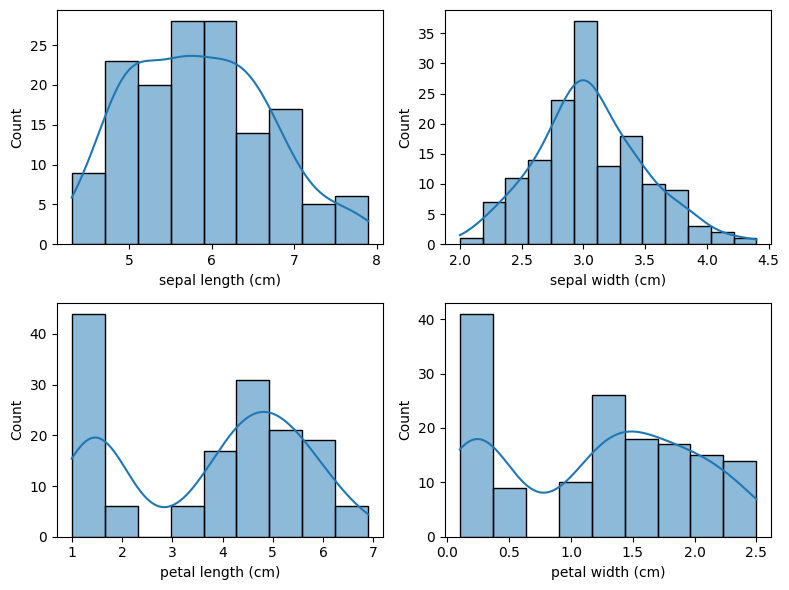

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (8, 6))
sns.histplot(features['sepal length (cm)'], kde = True, ax = ax[0, 0])
sns.histplot(features['sepal width (cm)'], kde = True, ax = ax[0, 1])
sns.histplot(features['petal length (cm)'], kde = True, ax = ax[1, 0])
sns.histplot(features['petal width (cm)'], kde = True, ax = ax[1, 1])
plt.tight_layout()
plt.show()

In [ ]:
label.name

'target'

In [ ]:
type(label)

pandas.core.series.Series

In [ ]:
label.head()

,target
0,0
1,0
2,0
3,0
4,0


In [ ]:
label.value_counts()

,count
target,
0,50
1,50
2,50


<Axes: xlabel='target', ylabel='Count'>

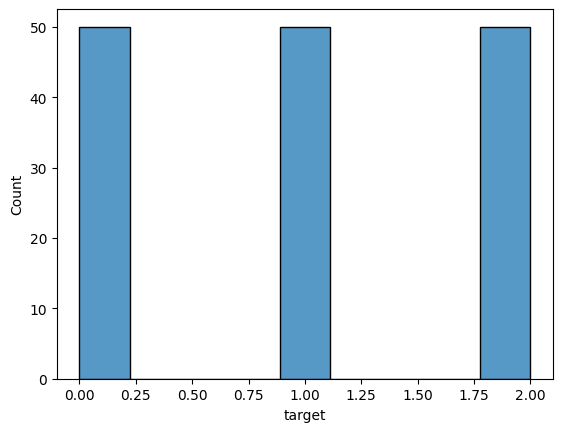

In [ ]:
sns.histplot(label)

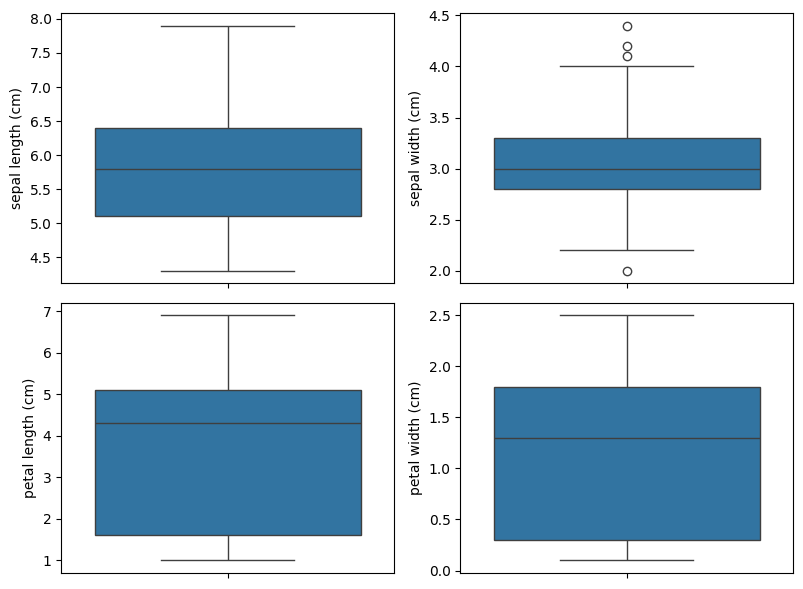

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (8, 6))
sns.boxplot(data = data, y = 'sepal length (cm)', ax = ax[0, 0])
sns.boxplot(data = data, y = 'sepal width (cm)', ax = ax[0, 1])
sns.boxplot(data = data, y = 'petal length (cm)', ax = ax[1, 0])
sns.boxplot(data = data, y = 'petal width (cm)', ax = ax[1, 1])
plt.tight_layout()
plt.show()

**Bivariate Analysis**

**Combine Features ans Labels**

In [ ]:
data = pd.merge(features, label, right_index= True, left_index= True)
data.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


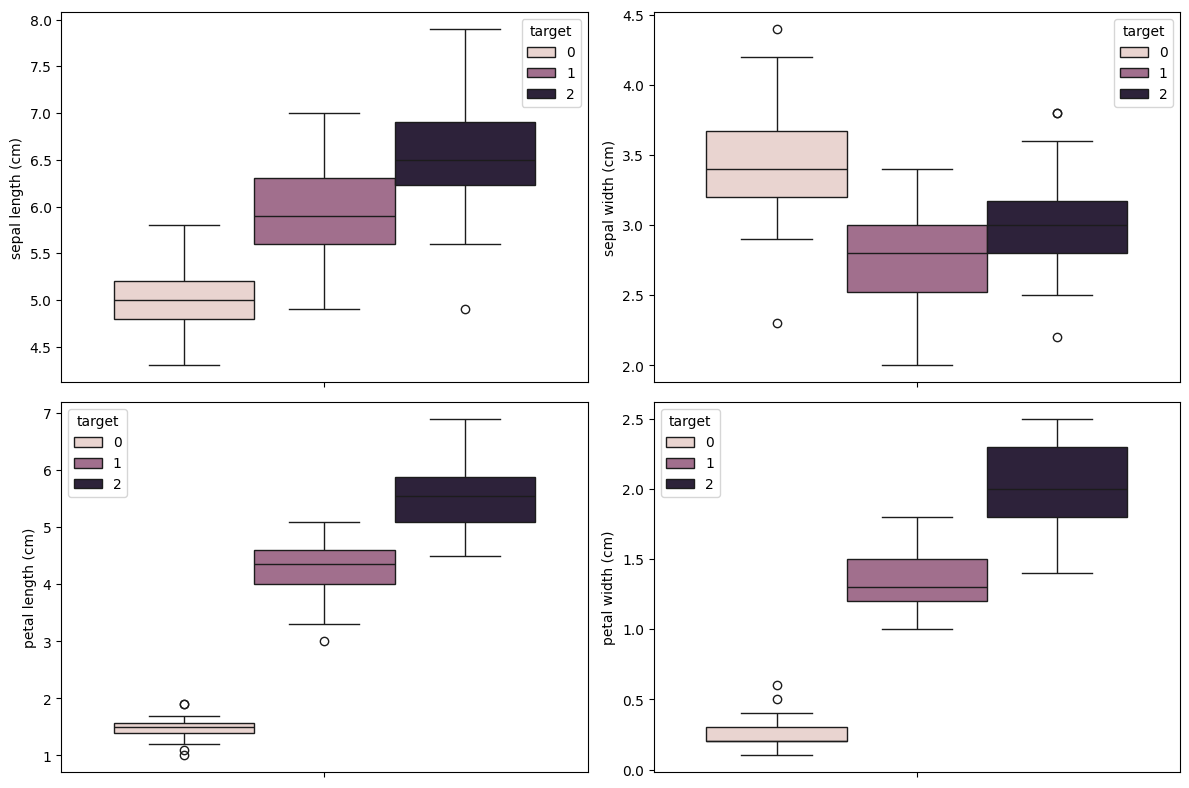

In [ ]:
fig, ax = plt.subplots(2, 2, figsize = (12, 8))
sns.boxplot(data = data, y = 'sepal length (cm)', hue = 'target', ax = ax[0, 0])
sns.boxplot(data = data, y = 'sepal width (cm)', hue = 'target', ax = ax[0, 1])
sns.boxplot(data = data, y = 'petal length (cm)', hue = 'target', ax = ax[1, 0])
sns.boxplot(data = data, y = 'petal width (cm)', hue = 'target', ax = ax[1, 1])
plt.tight_layout()
plt.show()

**Important Observation:**

- It looks like various Species are widely separated based on SepalLengthCm, PetalLengthCm and PetalWidthCm individually.
- Species have some overlaps based on SepalWidthCm.

<Axes: >

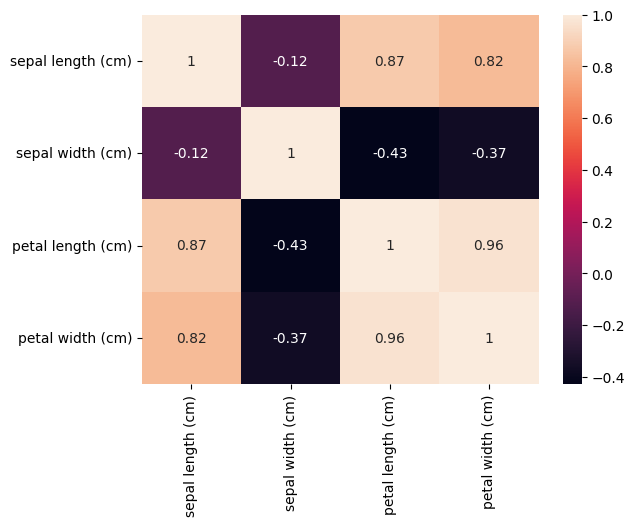

In [ ]:
sns.heatmap(data.iloc[:, :-1].corr(), annot = True)

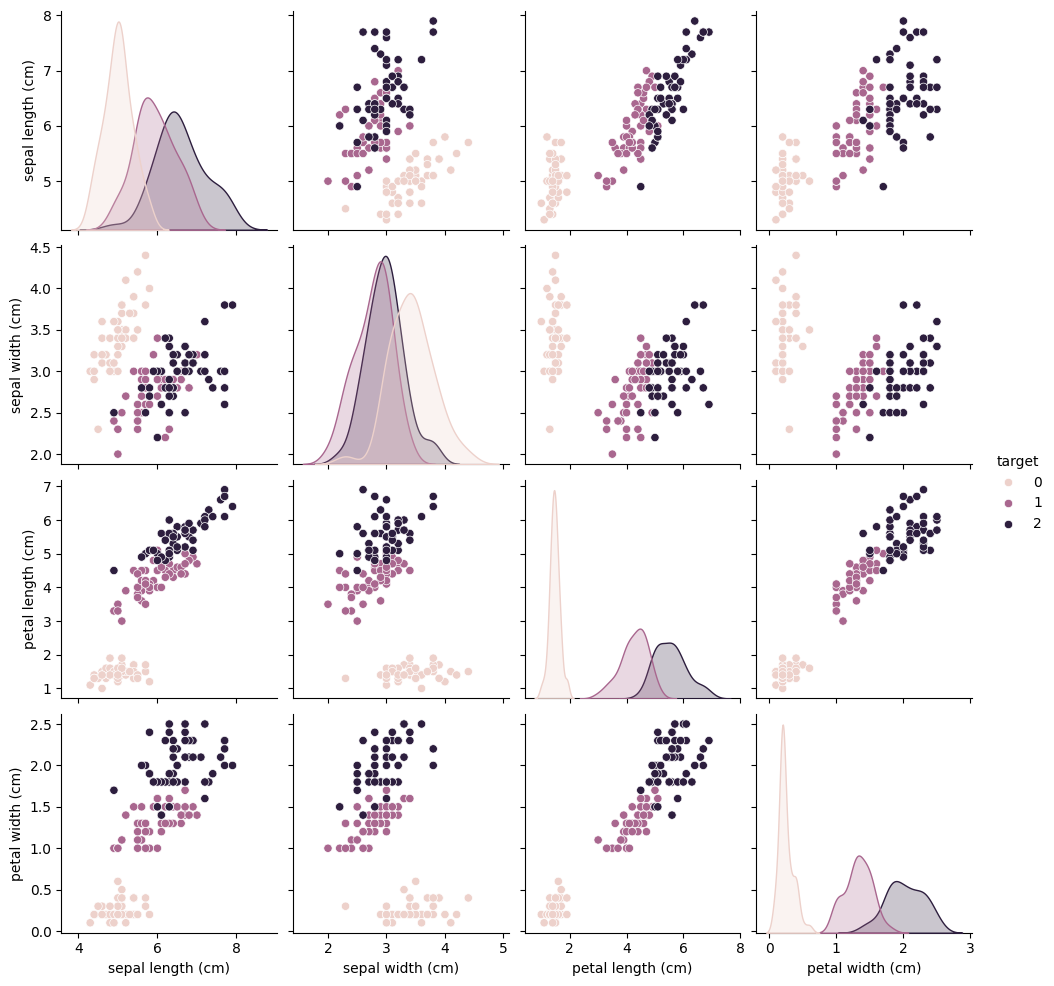

In [ ]:
sns.pairplot(data, hue = 'target')

**Important Observation:**

It looks like I don't have to consider all 4 variables to build my model. I can consider either one of the following pair:
1. PetalLength and SepalLength
2. PetalLength and SepalWidth
3. PetalLength and PetalWidth
4. PetalWidth and SepalLength


### 3. Segregate the Features and Target
* Segregate the predictor variables and Target variable
* Predictor variables(x) are SepalLengthCm, SepalWidthCm, PetalLengthCm and  PetalWidthCm.
* Target variable (y) is Species

In [ ]:
x = data.iloc[:, :-1]
y = data.iloc[:, -1]
x.shape, y.shape

((150, 4), (150,))

In [ ]:
x.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [ ]:
y.head()

,target
0,0
1,0
2,0
3,0
4,0


### 4. Split the data into Training and Testing Data
* Split into train and test (X_train, X_test, y_train, y_test)


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.3)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((105, 4), (45, 4), (105,), (45,))

### 5. (Training) Data Preparation
* Apply data preparation on the Training Data


In machine learning, the **data preparation phase** involves all the essential steps to build a clean, structured dataset ready for modeling. This includes handling outliers, engineering and transforming variables, normalizing features, reducing dimensionality, and imputing missing values. These steps are often **iterative**, adapting based on how well the data supports model performance and validation.

Real-world datasets are rarely clean—they often originate from multiple disconnected sources, contain noise or duplicates, and require extensive preprocessing to become usable for training models.

Since there’s no such thing as perfect data, understanding and preparing it becomes a crucial part of any ML pipeline. In fact, studies suggest that **over 75% of the total effort in a data mining or machine learning project** goes into data exploration and preparation. This stage lays the foundation for building robust, reliable models.

In [ ]:
scaler = StandardScaler().set_output(transform = 'pandas')
X_train_transformed = scaler.fit_transform(X_train)
X_train_transformed.shape

(105, 4)

In [ ]:
X_train_transformed[:5]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
81,-0.413416,-1.462003,-0.099511,-0.323398
133,0.551222,-0.502563,0.717703,0.353032
137,0.671802,0.217016,0.951192,0.758890
75,0.912961,-0.022844,0.309096,0.217746
109,1.636440,1.416315,1.301427,1.705891


**Characteristics of scaled data**

In [ ]:
print("Number of Numerical Features:", scaler.n_features_in_)
print("Mean of each column:", scaler.mean_)
print("Variance of each column:", scaler.var_)

Number of Numerical Features: 4
Mean of each column: [5.84285714 3.00952381 3.87047619 1.23904762]
Variance of each column: [0.68778231 0.17381406 2.93484263 0.54638005]


### 6. Model Building

**Modeling Phase**  
In this stage, different modeling algorithms are applied to the prepared dataset, and their parameters are tuned to optimize performance. Based on model evaluation (e.g., accuracy, AUC, loss), it may be necessary to revisit earlier phases like data preparation to improve fit.

**Choosing the Right Model Depends On:**
- **Model performance** (e.g., accuracy, interpretability, generalization)
- **Goal of analysis** (prediction vs. explanation)
- **Data size and processing speed requirements**

In [ ]:
logr = LogisticRegression()
logr.fit(X_train_transformed, y_train)

LogisticRegression()

### 7. (Testing) Data Preparation
* Apply data preparation on the Testing Data


In [ ]:
X_test_transformed = scaler.transform(X_test)
X_test_transformed.shape

(45, 4)

In [ ]:
X_test_transformed[:5]

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
73,0.310062,-0.502563,0.484213,-0.052826
18,-0.172257,1.896035,-1.266959,-1.270399
118,2.239339,-0.982283,1.768406,1.435319
78,0.189483,-0.262704,0.367468,0.353032
76,1.154121,-0.502563,0.542585,0.217746


In [ ]:
scaler.feature_names_in_

array(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'], dtype=object)

### 8. Prediction on Test Data
* Use the trained model to predict on test data

In [ ]:
y_test_pred = logr.predict(X_test_transformed)
y_test_pred.shape

(45,)

In [ ]:
y_test_pred[:5]

array([1, 0, 2, 1, 1])

In [ ]:
probs = logr.predict_proba(X_test_transformed)
probs[:5]

array([[1.26228313e-02, 8.61829363e-01, 1.25547806e-01],
       [9.68207360e-01, 3.17916874e-02, 9.52559968e-07],
       [6.77128309e-08, 3.69194549e-03, 9.96307987e-01],
       [1.45000607e-02, 7.37425287e-01, 2.48074652e-01],
       [2.25275952e-03, 7.29844648e-01, 2.67902592e-01]])

In [ ]:
print("Predicted class:", np.argmax(probs, axis = 1)[:5])

Predicted class: [1 0 2 1 1]


### 9. Evaluation

**Evaluation Phase (Model Validation & Business Alignment)**  
At this stage, the trained model(s) should demonstrate strong analytical performance. However, before deployment, they must be evaluated to ensure alignment with the project’s business goals. This includes:

- **Validating model performance** using appropriate metrics (e.g., accuracy, precision, recall, RMSE)  
- **Performing sensitivity analysis** to test robustness under varying input conditions  
- **Assessing business impact** to uncover any overlooked strategic considerations

The final step is to decide whether the model’s insights are ready for operational use, refinement, or rejection.

In [ ]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [ ]:
print('Accuracy score: ',metrics.accuracy_score(y_test, y_test_pred))

Accuracy score:  1.0


### Other models

In [ ]:
svm = SVC()
svm.fit(X_train_transformed, y_train)
y_test_pred = svm.predict(X_test_transformed)
y_test_pred[:5]

array([1, 0, 2, 1, 1])

In [ ]:
scores = svm.decision_function(X_test_transformed)
scores[:5]

array([[-0.22237809,  2.23290652,  0.92016129],
       [ 2.22377413,  0.87742317, -0.19788105],
       [-0.17232446,  0.85325905,  2.21664876],
       [-0.22650515,  2.21978415,  1.05196572],
       [-0.21992962,  2.20369579,  1.08968277]])

In [ ]:
np.argmax(scores, axis = 1)[:5]

array([1, 0, 2, 1, 1])

In [ ]:
metrics.accuracy_score(y_true = y_test, y_pred = y_test_pred)

1.0

In [ ]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [ ]:
# svm.LinearSVC (setting multi_class=”ovr”)
svm = LinearSVC(multi_class='ovr')
svm.fit(X_train_transformed, y_train)
y_test_pred = svm.predict(X_test_transformed)
metrics.accuracy_score(y_true = y_test, y_pred = y_test_pred)

0.9555555555555556

In [ ]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[19,  0,  0],
       [ 0, 11,  2],
       [ 0,  0, 13]])

In [ ]:
knn = KNeighborsClassifier()
knn.fit(X_train_transformed, y_train)
y_test_pred = knn.predict(X_test_transformed)
metrics.accuracy_score(y_true = y_test, y_pred = y_test_pred)

1.0

In [ ]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [ ]:
dt = DecisionTreeClassifier()
dt.fit(X_train_transformed, y_train)
y_test_pred = dt.predict(X_test_transformed)
metrics.accuracy_score(y_true = y_test, y_pred = y_test_pred)

1.0

In [ ]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train_transformed, y_train)
y_test_pred = rf.predict(X_test_transformed)
metrics.accuracy_score(y_true = y_test, y_pred = y_test_pred)

1.0

In [ ]:
metrics.confusion_matrix(y_test, y_test_pred)

array([[19,  0,  0],
       [ 0, 13,  0],
       [ 0,  0, 13]])

### Multilabel Output
https://scikit-learn.org/stable/modules/multiclass.html

In [ ]:
X = iris.data
# Create multilabels from y
# Example: [is_setosa, is_virginica, is_versicolor]
y_multilabel = np.array([[int(target == 0), int(target == 1), int(target == 2)] for target in y])
y_multilabel[:5]

array([[1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0],
       [1, 0, 0]])

In [ ]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y_multilabel, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((120, 4), (30, 4), (120, 3), (30, 3))

In [ ]:
# Wrap with MultiOutputClassifier
multi_target_clf = MultiOutputClassifier(RandomForestClassifier())
multi_target_clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = multi_target_clf.predict(X_test)
y_pred[:5]

array([[0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0]])

In [ ]:
y_test[:5]

array([[0, 1, 0],
       [1, 0, 0],
       [0, 0, 1],
       [0, 1, 0],
       [0, 1, 0]])

In [ ]:
metrics.accuracy_score(y_test, y_pred)

1.0